**Importy**

In [1]:
import pandas as pd

from scripts.helper.features_wrapper import (ensure_train_features_npz,ensure_test_features_npz,compute_pca_for_feature)
from scripts.dataset.unpack_root_dataset import main_unpack
from scripts.dataset.create_splits import create_splits, convert_class_name_to_index
from scripts.scaler import rescale_all_images, INPUT_DIR
from scripts.classifiers.svm import SVMClassifier
from scripts.classifiers.random_forests import RandomForestClassifier
from scripts.classifiers.metrics import calculate_metrics, plot_confusion_matrix

**Zmienne**

In [2]:
FORCE_REEXTRACT = False #jeśli True robi wszystko od nowa, jeśli False to sprawdza czy pliki istnieją i reszte pomija

**Robienie datasetu**

In [3]:
main_unpack(force_extract=FORCE_REEXTRACT)
create_splits(force_extract=FORCE_REEXTRACT)

Dataset already exists and is not empty. Skipping unpacking.
CSV splits already exist. Skipping creation.


**Przeskalowanie + padding**

In [4]:
from scripts.scaler import rescale_all_images

rescale_all_images(force_extract=FORCE_REEXTRACT)

Rescaled dataset already exists and is not empty. Skipping unpacking.


Wczytanie obrazów

In [5]:
from scripts.obrobka.wczytaj_obrazy import load_images

train_images, train_paths = load_images("train", scaled=True)
test_images, test_paths = load_images("test", scaled=True)

print("Liczba obrazów w train:", len(train_images))
print("Kształt pierwszego obrazu:", train_images[0].shape)
print("Liczba obrazów w test:", len(test_images))
print("Kształt pierwszego obrazu w teście:", test_images[0].shape)

Liczba obrazów w train: 6107
Kształt pierwszego obrazu: (256, 256, 3)
Liczba obrazów w test: 1527
Kształt pierwszego obrazu w teście: (256, 256, 3)


Sprawdzenie ile w każdej klasie mamy obrazów

In [6]:
train = pd.read_csv("dataset/train.csv")
print("\nTRAIN:")
print(train["class"].value_counts())
print("SUMA:", len(train))

test = pd.read_csv("dataset/test.csv")
print("\nTEST:")
print(test["class"].value_counts())
print("SUMA:", len(test))



TRAIN:
class
rhino       1102
zebra       1065
elephant    1032
lion        1009
giraffe      991
cheetah      908
Name: count, dtype: int64
SUMA: 6107

TEST:
class
rhino       287
lion        268
zebra       256
elephant    256
cheetah     242
giraffe     218
Name: count, dtype: int64
SUMA: 1527


Usuwanie tła --> nie widze narazie sensu ze względu na brak możliwości użycia sieci neuronowych

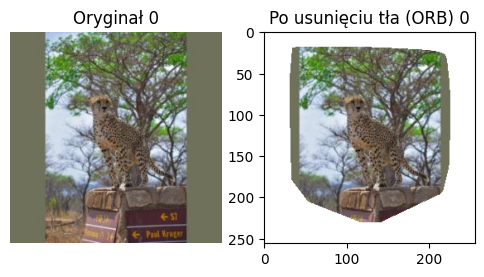

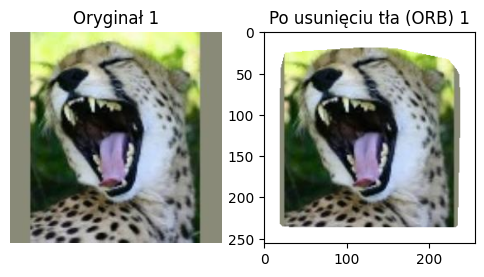

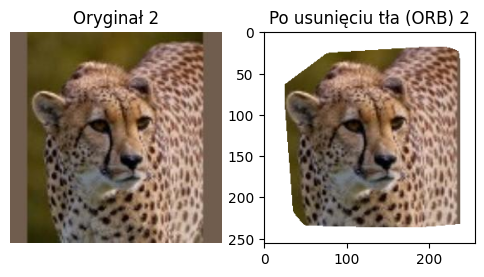

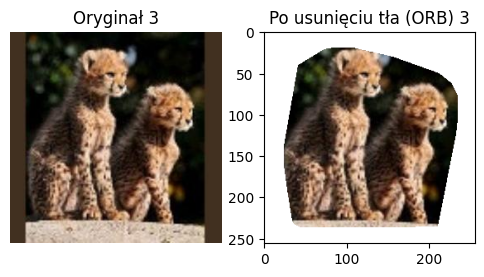

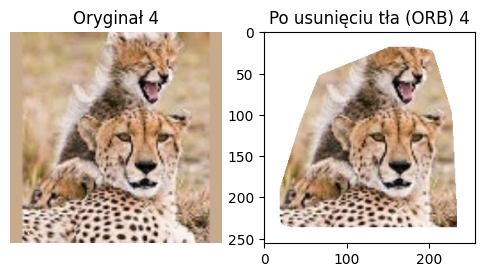

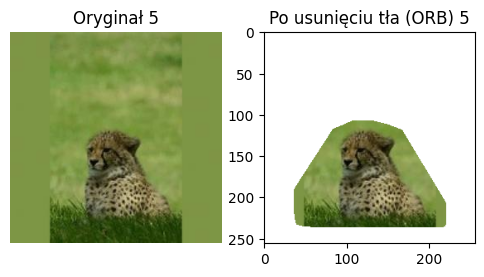

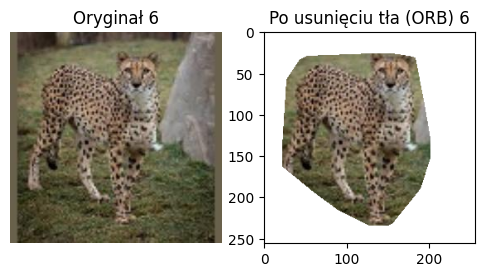

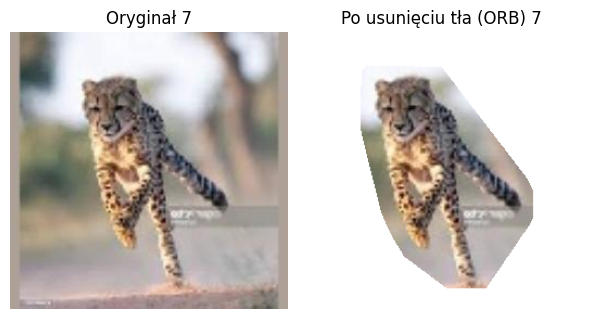

In [7]:
from scripts.obrobka.wczytaj_obrazy import load_images
from scripts.obrobka.usuniecie_tla import remove_background_from_image
import matplotlib.pyplot as plt

train_images, train_paths = load_images("train", scaled=True)

for i in range(8):
    img = train_images[i]
    fg = remove_background_from_image(img,nfeatures=2000,margin_frac=0.1)

    plt.figure(figsize=(6, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Oryginał {i}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(fg)
    plt.title(f"Po usunięciu tła (ORB) {i}")

plt.axis("off")
plt.tight_layout()
plt.show()


Teraz wydobywamy cechy z obrazów

metoda z użyciem HOG + PCA

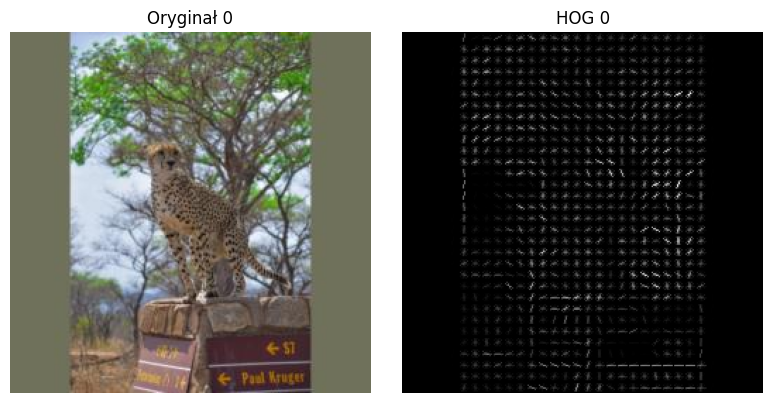

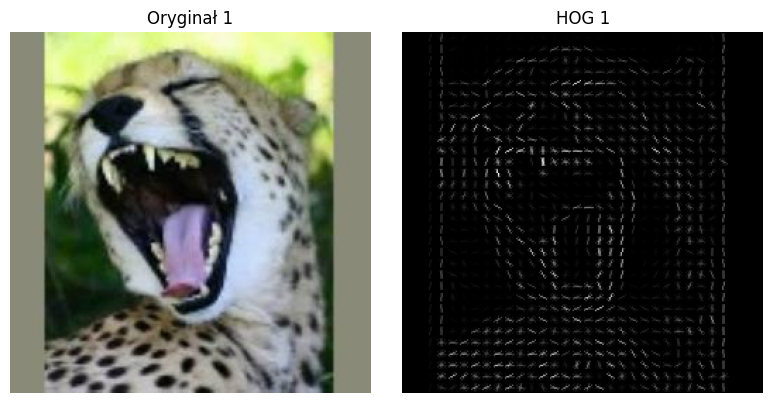

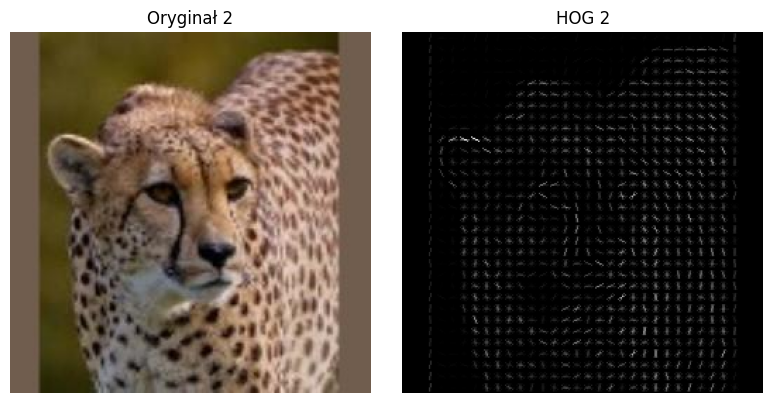

Kształt HOG train: (6107, 34596)
Kształt HOG test: (1527, 34596)
PCA
Kształt PCA train: (6107, 200)
Kształt PCA test: (1527, 200)


In [12]:
from scripts.obrobka.wczytaj_obrazy import load_images
from scripts.nowe_metody.hog_features_new import policz_hog_batch
from scripts.nowe_metody.pca_utils import (dopasuj_pca_nkomp,dopasuj_pca_wariancja,przeksztalc_pca,)
from scripts.nowe_metody.wizualizacja_hog import pokaz_hog


#wizualziacja
for i in range(3):
    pokaz_hog(train_images[i], idx=i)

#Hog dla całości
X_train_hog = policz_hog_batch(train_images)
X_test_hog = policz_hog_batch(test_images)
print("Kształt HOG train:", X_train_hog.shape)
print("Kształt HOG test:", X_test_hog.shape)


#PCA wariant  nr 1 --> stała liczba komponentów (64)
print("PCA")
pca, X_train_pca = dopasuj_pca_nkomp(X_train_hog, n_components=200)
#pca, X_train_pca = dopasuj_pca_nkomp(X_train_hog, n_components=128)
X_test_pca = przeksztalc_pca(pca, X_test_hog)
print("Kształt PCA train:", X_train_pca.shape)
print("Kształt PCA test:", X_test_pca.shape)

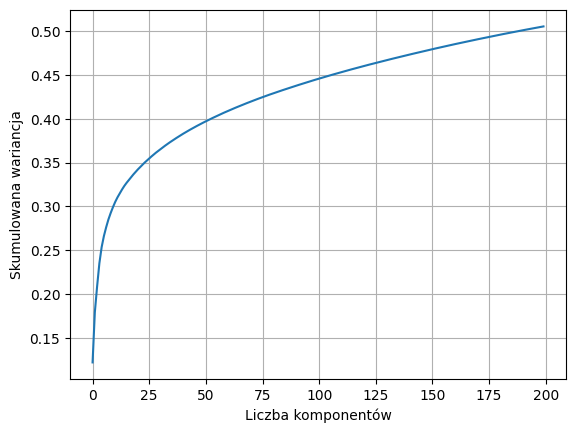

In [8]:
from scripts.nowe_metody.pca_utils import policz_skumulowana_wariancje
import matplotlib.pyplot as plt

variances = policz_skumulowana_wariancje(X_train_hog, max_components=200)
plt.plot(variances)
plt.xlabel("Liczba komponentów")
plt.ylabel("Skumulowana wariancja")
plt.grid(True)
plt.show()


Wczytanie etykiet z datasetu

In [9]:
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print("Klasy:", class_names)
print("Przykładowe etykiety train:", y_train[:10])

Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']
Przykładowe etykiety train: ['cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah'
 'cheetah' 'cheetah' 'cheetah']


SVM

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)

In [11]:
svm = SVMClassifier()

#strojenie hiperparametrów
best_params, best_cv_score = svm.tune_parameters(X_train_scaled, y_train, cv=3)
print("Najlepsze parametry:", best_params)
print(f"Średnia accuracy w CV: {best_cv_score:.4f}")

print("Trenowanie SVM...")
svm.fit(X_train_scaled, y_train)

#predykcja na testowym
print("Predykcja na zbiorze testowym...")
y_pred = svm.predict(X_test_scaled)

Najlepsze parametry: {'estimator__kernel': 'rbf', 'estimator__gamma': 'scale', 'estimator__C': 1}
Średnia accuracy w CV: 0.4442
Trenowanie SVM...
Predykcja na zbiorze testowym...


Metryki

Metryki SVM (HOG + PCA):
Accuracy:          0.5311
Precision (macro): 0.5383
Recall (macro):    0.5364
Specificity:       0.9064
F1 (macro):        0.5313
Balanced accuracy: 0.5364


<Figure size 600x600 with 0 Axes>

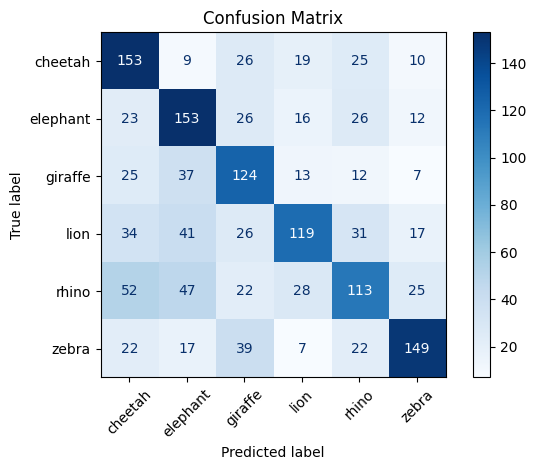

In [12]:
accuracy, precision, recall, specificity, f1, balanced_acc = calculate_metrics(y_test, y_pred)

print("Metryki SVM (HOG + PCA):")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"Specificity:       {specificity:.4f}")
print(f"F1 (macro):        {f1:.4f}")
print(f"Balanced accuracy: {balanced_acc:.4f}")

plot_confusion_matrix(y_test,y_pred,labels=class_names)

## HOG + kolor (na małych komórkach, dużo cech)

Liczenie rozszerzonego HOG (RGB + histogram koloru)...
Kształt HOG+kolor train: (6107, 103836)
Kształt HOG+kolor test: (1527, 103836)
PCA
Kształt PCA train: (6107, 200)
Kształt PCA test: (1527, 200)
Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']
Przykładowe etykiety train: ['cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah'
 'cheetah' 'cheetah' 'cheetah']
Trenowanie SVM (bez GridSearch)...
Predykcja na zbiorze testowym...
Metryki SVM (HOG + PCA):
Accuracy:          0.5573
Precision (macro): 0.5701
Recall (macro):    0.5611
Specificity:       0.9115
F1 (macro):        0.5599
Balanced accuracy: 0.5611


<Figure size 600x600 with 0 Axes>

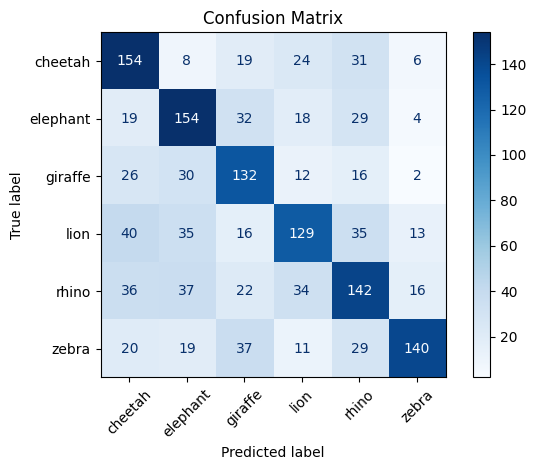

In [ ]:
from scripts.obrobka.wczytaj_obrazy import load_images
from scripts.nowe_metody.hog_color_features_new import policz_hog_kolor_batch
from scripts.nowe_metody.pca_utils import (dopasuj_pca_nkomp, przeksztalc_pca)

# HOG+kolor dla całości
print("Liczenie rozszerzonego HOG (RGB + histogram koloru)...")
X_train_hog = policz_hog_kolor_batch(train_images)
X_test_hog = policz_hog_kolor_batch(test_images)
print("Kształt HOG+kolor train:", X_train_hog.shape)
print("Kształt HOG+kolor test:", X_test_hog.shape)

#PCA wariant  nr 1 --> stała liczba komponentów (64)
print("PCA")
pca, X_train_pca = dopasuj_pca_nkomp(X_train_hog, n_components=200)
#pca, X_train_pca = dopasuj_pca_nkomp(X_train_hog, n_components=128)
X_test_pca = przeksztalc_pca(pca, X_test_hog)
print("Kształt PCA train:", X_train_pca.shape)
print("Kształt PCA test:", X_test_pca.shape)

train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print("Klasy:", class_names)
print("Przykładowe etykiety train:", y_train[:10])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)

#================================ STARA CZĘŚĆ
# wyłączam bo bardzo długo trwa mozna pozniej odblokowac
#svm = SVMClassifier()
#strojenie hiperparametrów =======
#best_params, best_cv_score = svm.tune_parameters(X_train_scaled, y_train, cv=3)
#print("Najlepsze parametry:", best_params)
#print(f"Średnia accuracy w CV: {best_cv_score:.4f}")
#print("Trenowanie SVM...")
#svm.fit(X_train_scaled, y_train)
#=============================== OD tąd nowa część
#zamiast tego wyżej wpisuję ręcznie najlepsze parametry z poprzedniego strojenia
print("Trenowanie SVM (bez GridSearch)...")
svm = SVMClassifier(C=10.0, kernel="rbf", gamma="scale")
svm.fit(X_train_scaled, y_train)
#============================== Tu sie kończy

#predykcja na testowym
print("Predykcja na zbiorze testowym...")
y_pred = svm.predict(X_test_scaled)

accuracy, precision, recall, specificity, f1, balanced_acc = calculate_metrics(y_test, y_pred)

print("Metryki SVM (HOG + PCA):")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"Specificity:       {specificity:.4f}")
print(f"F1 (macro):        {f1:.4f}")
print(f"Balanced accuracy: {balanced_acc:.4f}")

plot_confusion_matrix(y_test,y_pred,labels=class_names)

## 56% Skuteczości

czyli lepiej niż poprzednie 53 % ale nadal nie jest super

## ciag dalszy testów 
## HOG + kolor_wersja 2 (na większych komórkach, mniej szumu)

Wybrane najlepsze parametry: {'C': 3, 'gamma': 'scale'} (CV accuracy: 0.4505)

Liczenie rozszerzonego HOG (RGB + histogram koloru)...
Kształt HOG+kolor train: (6107, 24348)
Kształt HOG+kolor test: (1527, 24348)
Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']
Przykładowe etykiety train: ['cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah'
 'cheetah' 'cheetah' 'cheetah']
PCA
Kształt PCA train: (6107, 200)
Kształt PCA test: (1527, 200)
Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']
Przykładowe etykiety train: ['cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah'
 'cheetah' 'cheetah' 'cheetah']
Trenowanie SVM (bez GridSearch)...
Predykcja na zbiorze testowym...
Metryki SVM (HOG + PCA):
Accuracy:          0.5756
Precision (macro): 0.5806
Recall (macro):    0.5780
Specificity:       0.9150
F1 (macro):        0.5777
Balanced accuracy: 0.5780


<Figure size 600x600 with 0 Axes>

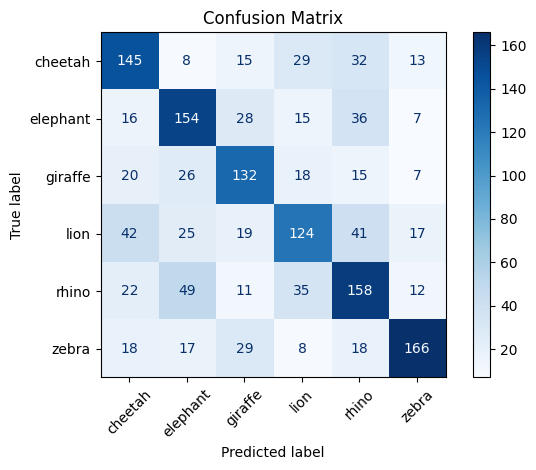

In [ ]:
from scripts.obrobka.wczytaj_obrazy import load_images
from scripts.nowe_metody.hog_color_features_new2 import policz_hog_kolor2_batch
from scripts.nowe_metody.pca_utils import (dopasuj_pca_nkomp, przeksztalc_pca)
from sklearn.preprocessing import StandardScaler


#HOG+kolor dla całości
print("Liczenie rozszerzonego HOG (RGB + histogram koloru)...")
X_train_hog = policz_hog_kolor2_batch(train_images)
X_test_hog = policz_hog_kolor2_batch(test_images)
print("Kształt HOG+kolor train:", X_train_hog.shape)
print("Kształt HOG+kolor test:", X_test_hog.shape)

#Wczytanie etykiet
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print("Klasy:", class_names)
print("Przykładowe etykiety train:", y_train[:10])

#PCA wariant  nr 1 --> stała liczba komponentów (64)
print("PCA")
pca, X_train_pca = dopasuj_pca_nkomp(X_train_hog, n_components=200)
#pca, X_train_pca = dopasuj_pca_nkomp(X_train_hog, n_components=128)
X_test_pca = przeksztalc_pca(pca, X_test_hog)
print("Kształt PCA train:", X_train_pca.shape)
print("Kształt PCA test:", X_test_pca.shape)

train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print("Klasy:", class_names)
print("Przykładowe etykiety train:", y_train[:10])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)

print("Trenowanie SVM (bez GridSearch)...")
svm = SVMClassifier(C=3.0, kernel="rbf", gamma="scale") #najlepsze do tej pory
svm.fit(X_train_scaled, y_train)

#predykcja na testowym
print("Predykcja na zbiorze testowym...")
y_pred = svm.predict(X_test_scaled)

accuracy, precision, recall, specificity, f1, balanced_acc = calculate_metrics(y_test, y_pred)

print("Metryki SVM (HOG + PCA):")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"Specificity:       {specificity:.4f}")
print(f"F1 (macro):        {f1:.4f}")
print(f"Balanced accuracy: {balanced_acc:.4f}")

plot_confusion_matrix(y_test,y_pred,labels=class_names)


Skuteczność podniosła się do 57.5 %

## Nowe --> informacja o przestrzenna o kolorze (gdzie jest mnie więcej na obrazach)

Liczenie HOG+kolor+spatial (RGB + HSV + 2x2)...
Kształt HOG+kolor train: (6107, 24540)
Kształt HOG+kolor test: (1527, 24540)
Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']
Przykładowe etykiety train: ['cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah'
 'cheetah' 'cheetah' 'cheetah']
PCA
Kształt PCA train: (6107, 200)
Kształt PCA test: (1527, 200)
Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']
Przykładowe etykiety train: ['cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah'
 'cheetah' 'cheetah' 'cheetah']
Trenowanie SVM (bez GridSearch)...
Predykcja na zbiorze testowym...
Metryki SVM (HOG + PCA):
Accuracy:          0.5920
Precision (macro): 0.5943
Recall (macro):    0.5951
Specificity:       0.9185
F1 (macro):        0.5928
Balanced accuracy: 0.5951


<Figure size 600x600 with 0 Axes>

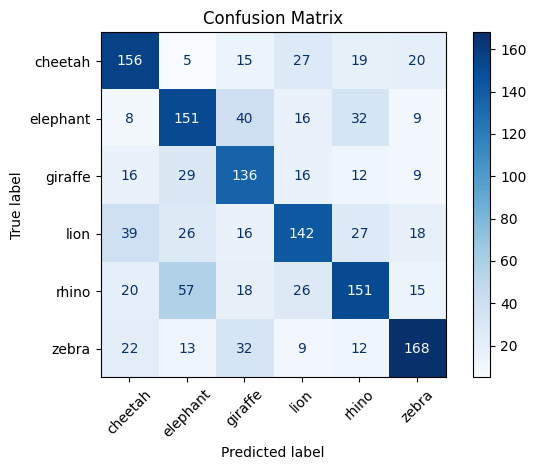

In [6]:
from scripts.obrobka.wczytaj_obrazy import load_images
from scripts.nowe_metody.hog_color_spatial import policz_hog_kolor_spatial_batch
from scripts.nowe_metody.pca_utils import (dopasuj_pca_nkomp, przeksztalc_pca)
from sklearn.preprocessing import StandardScaler


#HOG+kolor dla całości
print("Liczenie HOG+kolor+spatial (RGB + HSV + 2x2)...")
X_train_hog = policz_hog_kolor_spatial_batch(train_images)
X_test_hog = policz_hog_kolor_spatial_batch(test_images)
print("Kształt HOG+kolor train:", X_train_hog.shape)
print("Kształt HOG+kolor test:", X_test_hog.shape)

#Wczytanie etykiet
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print("Klasy:", class_names)
print("Przykładowe etykiety train:", y_train[:10])

#PCA wariant  nr 1 --> stała liczba komponentów (64)
print("PCA")
pca, X_train_pca = dopasuj_pca_nkomp(X_train_hog, n_components=200)
#pca, X_train_pca = dopasuj_pca_nkomp(X_train_hog, n_components=128)
X_test_pca = przeksztalc_pca(pca, X_test_hog)
print("Kształt PCA train:", X_train_pca.shape)
print("Kształt PCA test:", X_test_pca.shape)

train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print("Klasy:", class_names)
print("Przykładowe etykiety train:", y_train[:10])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)

print("Trenowanie SVM (bez GridSearch)...")
svm = SVMClassifier(C=3.0, kernel="rbf", gamma="scale") #najlepsze do tej pory
svm.fit(X_train_scaled, y_train)

#predykcja na testowym
print("Predykcja na zbiorze testowym...")
y_pred = svm.predict(X_test_scaled)

accuracy, precision, recall, specificity, f1, balanced_acc = calculate_metrics(y_test, y_pred)

print("Metryki SVM (HOG + PCA):")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"Specificity:       {specificity:.4f}")
print(f"F1 (macro):        {f1:.4f}")
print(f"Balanced accuracy: {balanced_acc:.4f}")

plot_confusion_matrix(y_test,y_pred,labels=class_names)


Wzrost do 59% jupii

## Hog + kolo+ spatial PCA + BOVW (SIFT) (kod poniżej to ten z BOVW) 

Liczenie HOG+kolor+spatial (RGB + HSV + 2x2)...
Kształt HOG+kolor+spatial train: (6107, 24540)
Kształt HOG+kolor+spatial test: (1527, 24540)
Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']
Przykładowe etykiety train: ['cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah'
 'cheetah' 'cheetah' 'cheetah']
PCA na HOG...
Kształt HOG_PCA train: (6107, 200)
Kształt HOG_PCA test: (1527, 200)

Budowa słownika BoVW (SIFT + MiniBatchKMeans)...
Zbieram deskryptory SIFT do budowy słownika
Łączna liczba deskryptorów do KMeans: 389911
trening MiniBatchKMeans (słownik BoVW)...
Init 1/1 with method k-means++
Inertia for init 1/1: 339691968.0
[MiniBatchKMeans] Reassigning 21 cluster centers.
Minibatch step 1/38991: mean batch inertia: 112120.2
Minibatch step 2/38991: mean batch inertia: 91155.736, ewa inertia: 91155.736
Minibatch step 3/38991: mean batch inertia: 86515.024, ewa inertia: 91131.93210578797
Minibatch step 4/38991: mean batch inertia: 86047.768, ewa inert

<Figure size 600x600 with 0 Axes>

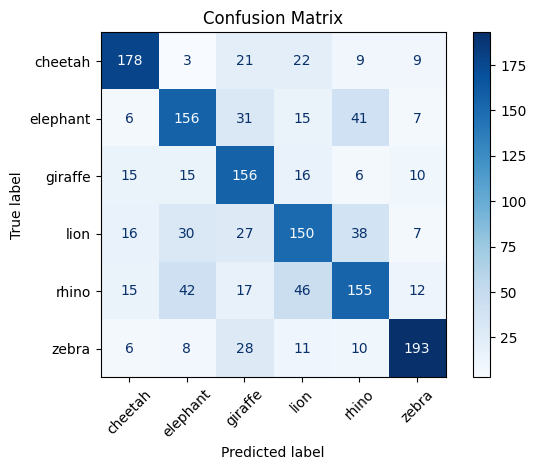

In [6]:
import numpy as np
from scripts.obrobka.wczytaj_obrazy import load_images
from scripts.nowe_metody.hog_color_spatial import policz_hog_kolor_spatial_batch
from scripts.nowe_metody.pca_utils import (dopasuj_pca_nkomp, przeksztalc_pca)
from scripts.nowe_metody.BOVW_sift import (zbuduj_slownik_sift_bovw,policz_bovw_dla_obrazow)
from sklearn.preprocessing import StandardScaler

#HOG + kolor + spatial

print("Liczenie HOG+kolor+spatial (RGB + HSV + 2x2)...")
X_train_hog = policz_hog_kolor_spatial_batch(train_images)
X_test_hog = policz_hog_kolor_spatial_batch(test_images)
print("Kształt HOG+kolor+spatial train:", X_train_hog.shape)
print("Kształt HOG+kolor+spatial test:", X_test_hog.shape)

#etykiety
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print("Klasy:", class_names)
print("Przykładowe etykiety train:", y_train[:10])

#PCA na HOG+kolor+spatial
print("PCA na HOG...")
pca, X_train_hog_pca = dopasuj_pca_nkomp(X_train_hog, n_components=200)
X_test_hog_pca = przeksztalc_pca(pca, X_test_hog)
print("Kształt HOG_PCA train:", X_train_hog_pca.shape)
print("Kształt HOG_PCA test:", X_test_hog_pca.shape)

#skalowanie HOG_PCA
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog_pca)
X_test_hog_scaled = scaler_hog.transform(X_test_hog_pca)

#BoVW (SIFT)
from scripts.nowe_metody.BOVW_sift import zbuduj_slownik_sift_bovw, policz_bovw_dla_obrazow

print("\nBudowa słownika BoVW (SIFT + MiniBatchKMeans)...")
sift, kmeans = zbuduj_slownik_sift_bovw(
    train_images,
    n_clusters=256,       #liczba 'słów wizualnych'
    max_images=2000,      #ile max obrazów do budowy słownika
    max_kp_per_image=200, #max kluczowych punktów na obraz
    random_state=42,
)

print("Liczenie histogramów BoVW dla train/test...")
X_train_bovw = policz_bovw_dla_obrazow(train_images, sift, kmeans, max_kp_per_image=200)
X_test_bovw = policz_bovw_dla_obrazow(test_images, sift, kmeans, max_kp_per_image=200)
print("Kształt BoVW train:", X_train_bovw.shape)
print("Kształt BoVW test:", X_test_bovw.shape)

#skalowanie BoVW
scaler_bovw = StandardScaler()
X_train_bovw_scaled = scaler_bovw.fit_transform(X_train_bovw)
X_test_bovw_scaled = scaler_bovw.transform(X_test_bovw)

#COMBO --> [HOG_PCA | BoVW]
X_train_combo = np.hstack([X_train_hog_scaled, X_train_bovw_scaled])
X_test_combo = np.hstack([X_test_hog_scaled, X_test_bovw_scaled])

print("Kształt CECH COMBO train:", X_train_combo.shape)
print("Kształt CECH COMBO test:", X_test_combo.shape)

#SVM na cechach combo
print("Trenowanie SVMClassifier na cechach COMBO...")
svm = SVMClassifier(C=3.0, kernel="rbf", gamma="scale")
svm.fit(X_train_combo, y_train)

print("Predykcja na zbiorze testowym (COMBO)...")
y_pred = svm.predict(X_test_combo)

accuracy, precision, recall, specificity, f1, balanced_acc = calculate_metrics(y_test, y_pred)

print("Metryki SVM (COMBO: HOG_PCA + BoVW):")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"Specificity:       {specificity:.4f}")
print(f"F1 (macro):        {f1:.4f}")
print(f"Balanced accuracy: {balanced_acc:.4f}")

plot_confusion_matrix(y_test, y_pred, labels=class_names)


Wow 65 % Skuteczności !!!!

Liczenie HOG+kolor+spatial (RGB + HSV + 2x2)...
Kształt HOG+kolor+spatial train: (6107, 24540)
Kształt HOG+kolor+spatial test: (1527, 24540)
Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']
Przykładowe etykiety train: ['cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah'
 'cheetah' 'cheetah' 'cheetah']
PCA na HOG...
Kształt HOG_PCA train: (6107, 200)
Kształt HOG_PCA test: (1527, 200)

Budowa słownika BoVW (SIFT + MiniBatchKMeans)...
Zbieram deskryptory SIFT do budowy słownika
Łączna liczba deskryptorów do KMeans: 389911
trening MiniBatchKMeans (słownik BoVW)...
Init 1/1 with method k-means++
Inertia for init 1/1: 320692352.0
[MiniBatchKMeans] Reassigning 114 cluster centers.
Minibatch step 1/38991: mean batch inertia: 106990.712
Minibatch step 2/38991: mean batch inertia: 92220.336, ewa inertia: 92220.336
Minibatch step 3/38991: mean batch inertia: 87296.264, ewa inertia: 92195.0786496235
Minibatch step 4/38991: mean batch inertia: 83730.056, ewa ine

<Figure size 600x600 with 0 Axes>

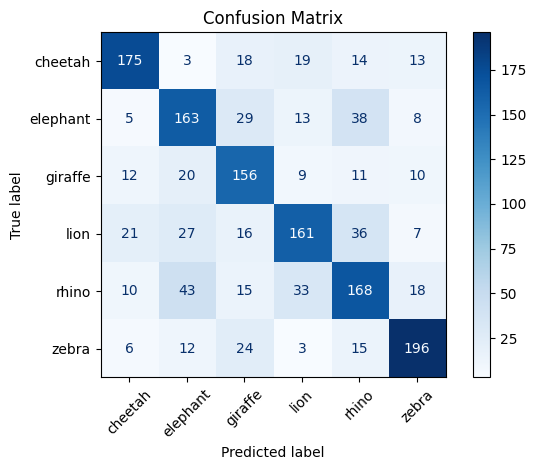

In [ ]:
import numpy as np
from scripts.obrobka.wczytaj_obrazy import load_images
from scripts.nowe_metody.hog_color_spatial import policz_hog_kolor_spatial_batch
from scripts.nowe_metody.pca_utils import (dopasuj_pca_nkomp, przeksztalc_pca)
from scripts.nowe_metody.BOVW_sift import (zbuduj_slownik_sift_bovw,policz_bovw_dla_obrazow)
from sklearn.preprocessing import StandardScaler

#HOG + kolor + spatial

print("Liczenie HOG+kolor+spatial (RGB + HSV + 2x2)...")
X_train_hog = policz_hog_kolor_spatial_batch(train_images)
X_test_hog = policz_hog_kolor_spatial_batch(test_images)
print("Kształt HOG+kolor+spatial train:", X_train_hog.shape)
print("Kształt HOG+kolor+spatial test:", X_test_hog.shape)

#etykiety
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print("Klasy:", class_names)
print("Przykładowe etykiety train:", y_train[:10])

#PCA na HOG+kolor+spatial
print("PCA na HOG...")
pca, X_train_hog_pca = dopasuj_pca_nkomp(X_train_hog, n_components=200)
X_test_hog_pca = przeksztalc_pca(pca, X_test_hog)
print("Kształt HOG_PCA train:", X_train_hog_pca.shape)
print("Kształt HOG_PCA test:", X_test_hog_pca.shape)

#skalowanie HOG_PCA
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog_pca)
X_test_hog_scaled = scaler_hog.transform(X_test_hog_pca)

#BoVW (SIFT)
from scripts.nowe_metody.BOVW_sift import zbuduj_slownik_sift_bovw, policz_bovw_dla_obrazow

print("\nBudowa słownika BoVW (SIFT + MiniBatchKMeans)...")
sift, kmeans = zbuduj_slownik_sift_bovw(
    train_images,
    n_clusters=512,       #liczba 'słów wizualnych'  ZWIĘKSZAM DO 512 z 256
    max_images=2000,      #ile max obrazów do budowy słownika
    max_kp_per_image=200, #max kluczowych punktów na obraz
    random_state=42,
)

print("Liczenie histogramów BoVW dla train/test...")
X_train_bovw = policz_bovw_dla_obrazow(train_images, sift, kmeans, max_kp_per_image=200)
X_test_bovw = policz_bovw_dla_obrazow(test_images, sift, kmeans, max_kp_per_image=200)
print("Kształt BoVW train:", X_train_bovw.shape)
print("Kształt BoVW test:", X_test_bovw.shape)

#skalowanie BoVW
scaler_bovw = StandardScaler()
X_train_bovw_scaled = scaler_bovw.fit_transform(X_train_bovw)
X_test_bovw_scaled = scaler_bovw.transform(X_test_bovw)

#nowosc-------
from sklearn.decomposition import PCA
print("PCA na BoVW...")
pca_bovw = PCA(n_components=64)
X_train_bovw_pca = pca_bovw.fit_transform(X_train_bovw_scaled)
X_test_bovw_pca = pca_bovw.transform(X_test_bovw_scaled)

print("Nowe kształty BoVW_PCA:", X_train_bovw_pca.shape, X_test_bovw_pca.shape)

#COMBO --> [HOG_PCA | BoVW]
X_train_combo = np.hstack([X_train_hog_scaled, X_train_bovw_pca])
X_test_combo = np.hstack([X_test_hog_scaled, X_test_bovw_pca])


#-------------

print("Kształt CECH COMBO train:", X_train_combo.shape)
print("Kształt CECH COMBO test:", X_test_combo.shape)

#SVM na cechach combo
print("Trenowanie SVMClassifier na cechach COMBO...")
svm = SVMClassifier(C=3.0, kernel="rbf", gamma="scale")
svm.fit(X_train_combo, y_train)

print("Predykcja na zbiorze testowym (COMBO)...")
y_pred = svm.predict(X_test_combo)

accuracy, precision, recall, specificity, f1, balanced_acc = calculate_metrics(y_test, y_pred)

print("Metryki SVM (COMBO: HOG_PCA + BoVW):")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"Specificity:       {specificity:.4f}")
print(f"F1 (macro):        {f1:.4f}")
print(f"Balanced accuracy: {balanced_acc:.4f}")

plot_confusion_matrix(y_test, y_pred, labels=class_names)


## 66% SKUTECZNOŚCI JEST SUPER !!!

## po przejrzeniu najlepszych parametrów dla SVM wyszło

Najlepsze parametry SVM dla COMBO: {'C': 3, 'gamma': 'scale'}

## Zmieniam HOG z 200 na 256 i PCA BOVW z 64 na 96

Liczenie HOG+kolor+spatial (RGB + HSV + 2x2)...
Kształt HOG+kolor+spatial train: (6107, 24540)
Kształt HOG+kolor+spatial test: (1527, 24540)
Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']
Przykładowe etykiety train: ['cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah'
 'cheetah' 'cheetah' 'cheetah']
PCA na HOG...
Kształt HOG_PCA train: (6107, 256)
Kształt HOG_PCA test: (1527, 256)

Budowa słownika BoVW (SIFT + MiniBatchKMeans)...
Zbieram deskryptory SIFT do budowy słownika
Łączna liczba deskryptorów do KMeans: 389911
trening MiniBatchKMeans (słownik BoVW)...
Init 1/1 with method k-means++
Inertia for init 1/1: 318304640.0
[MiniBatchKMeans] Reassigning 134 cluster centers.
Minibatch step 1/38991: mean batch inertia: 106439.936
Minibatch step 2/38991: mean batch inertia: 92422.792, ewa inertia: 92422.792
Minibatch step 3/38991: mean batch inertia: 86543.736, ewa inertia: 92392.636190484
Minibatch step 4/38991: mean batch inertia: 83338.688, ewa iner

<Figure size 600x600 with 0 Axes>

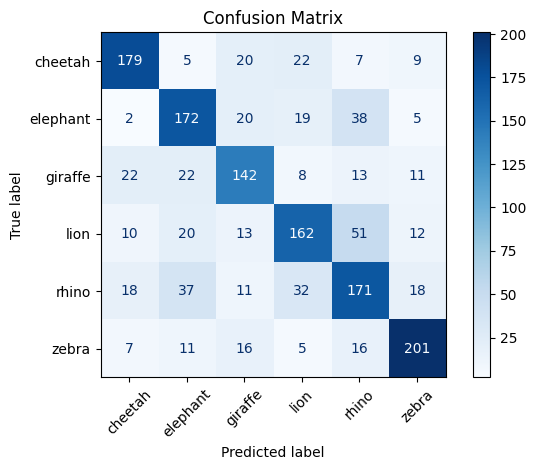

In [10]:
import numpy as np
from scripts.obrobka.wczytaj_obrazy import load_images
from scripts.nowe_metody.hog_color_spatial import policz_hog_kolor_spatial_batch
from scripts.nowe_metody.pca_utils import (dopasuj_pca_nkomp, przeksztalc_pca)
from scripts.nowe_metody.BOVW_sift import (zbuduj_slownik_sift_bovw,policz_bovw_dla_obrazow)
from sklearn.preprocessing import StandardScaler

#HOG + kolor + spatial

print("Liczenie HOG+kolor+spatial (RGB + HSV + 2x2)...")
X_train_hog = policz_hog_kolor_spatial_batch(train_images)
X_test_hog = policz_hog_kolor_spatial_batch(test_images)
print("Kształt HOG+kolor+spatial train:", X_train_hog.shape)
print("Kształt HOG+kolor+spatial test:", X_test_hog.shape)

#etykiety
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print("Klasy:", class_names)
print("Przykładowe etykiety train:", y_train[:10])

#PCA na HOG+kolor+spatial
print("PCA na HOG...")
pca, X_train_hog_pca = dopasuj_pca_nkomp(X_train_hog, n_components=256) #zwiększam do 256 z 200
X_test_hog_pca = przeksztalc_pca(pca, X_test_hog)
print("Kształt HOG_PCA train:", X_train_hog_pca.shape)
print("Kształt HOG_PCA test:", X_test_hog_pca.shape)

#skalowanie HOG_PCA
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog_pca)
X_test_hog_scaled = scaler_hog.transform(X_test_hog_pca)

#BoVW (SIFT)
from scripts.nowe_metody.BOVW_sift import zbuduj_slownik_sift_bovw, policz_bovw_dla_obrazow

print("\nBudowa słownika BoVW (SIFT + MiniBatchKMeans)...")
sift, kmeans = zbuduj_slownik_sift_bovw(
    train_images,
    n_clusters=512,       #liczba 'słów wizualnych'  ZWIĘKSZAM DO 512 z 256
    max_images=2000,      #ile max obrazów do budowy słownika
    max_kp_per_image=200, #max kluczowych punktów na obraz
    random_state=42,
)

print("Liczenie histogramów BoVW dla train/test...")
X_train_bovw = policz_bovw_dla_obrazow(train_images, sift, kmeans, max_kp_per_image=200)
X_test_bovw = policz_bovw_dla_obrazow(test_images, sift, kmeans, max_kp_per_image=200)
print("Kształt BoVW train:", X_train_bovw.shape)
print("Kształt BoVW test:", X_test_bovw.shape)

#skalowanie BoVW
scaler_bovw = StandardScaler()
X_train_bovw_scaled = scaler_bovw.fit_transform(X_train_bovw)
X_test_bovw_scaled = scaler_bovw.transform(X_test_bovw)

#nowosc-------
from sklearn.decomposition import PCA
print("PCA na BoVW...")
pca_bovw = PCA(n_components=96) #=================zmiana z 64 na 96
X_train_bovw_pca = pca_bovw.fit_transform(X_train_bovw_scaled)
X_test_bovw_pca = pca_bovw.transform(X_test_bovw_scaled)

print("Nowe kształty BoVW_PCA:", X_train_bovw_pca.shape, X_test_bovw_pca.shape)

#COMBO --> [HOG_PCA | BoVW]
X_train_combo = np.hstack([X_train_hog_scaled, X_train_bovw_pca])
X_test_combo = np.hstack([X_test_hog_scaled, X_test_bovw_pca])


#-------------

print("Kształt CECH COMBO train:", X_train_combo.shape)
print("Kształt CECH COMBO test:", X_test_combo.shape)

#SVM na cechach combo
print("Trenowanie SVMClassifier na cechach COMBO...")
svm = SVMClassifier(C=3.0, kernel="rbf", gamma="scale")
svm.fit(X_train_combo, y_train)

print("Predykcja na zbiorze testowym (COMBO)...")
y_pred = svm.predict(X_test_combo)

accuracy, precision, recall, specificity, f1, balanced_acc = calculate_metrics(y_test, y_pred)

print("Metryki SVM (COMBO: HOG_PCA + BoVW):")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"Specificity:       {specificity:.4f}")
print(f"F1 (macro):        {f1:.4f}")
print(f"Balanced accuracy: {balanced_acc:.4f}")

plot_confusion_matrix(y_test, y_pred, labels=class_names)


## Wzrosto do 67% skutezcności

próba zmiany max_kp_per_image z 200 na 300

Liczenie HOG+kolor+spatial (RGB + HSV + 2x2)...
Kształt HOG+kolor+spatial train: (6107, 24540)
Kształt HOG+kolor+spatial test: (1527, 24540)
Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']
Przykładowe etykiety train: ['cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah'
 'cheetah' 'cheetah' 'cheetah']
PCA na HOG...
Kształt HOG_PCA train: (6107, 256)
Kształt HOG_PCA test: (1527, 256)

Budowa słownika BoVW (SIFT + MiniBatchKMeans)...
Zbieram deskryptory SIFT do budowy słownika
Łączna liczba deskryptorów do KMeans: 389911
trening MiniBatchKMeans (słownik BoVW)...
Init 1/1 with method k-means++
Inertia for init 1/1: 321864928.0
[MiniBatchKMeans] Reassigning 110 cluster centers.
Minibatch step 1/38991: mean batch inertia: 106661.704
Minibatch step 2/38991: mean batch inertia: 91854.688, ewa inertia: 91854.688
Minibatch step 3/38991: mean batch inertia: 86722.496, ewa inertia: 91828.36312669524
Minibatch step 4/38991: mean batch inertia: 83953.864, ewa in

<Figure size 600x600 with 0 Axes>

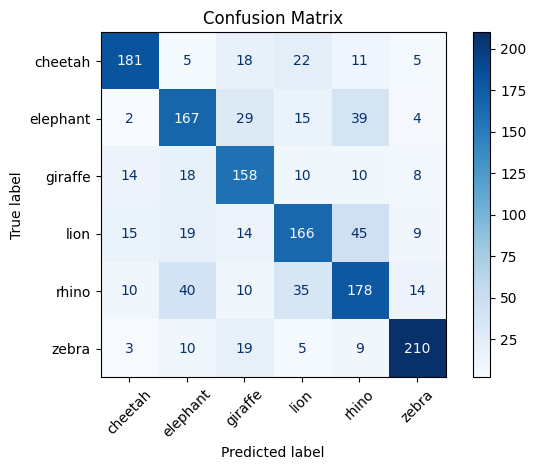

In [ ]:
import numpy as np
from scripts.obrobka.wczytaj_obrazy import load_images
from scripts.nowe_metody.hog_color_spatial import policz_hog_kolor_spatial_batch
from scripts.nowe_metody.pca_utils import (dopasuj_pca_nkomp, przeksztalc_pca)
from scripts.nowe_metody.BOVW_sift import (zbuduj_slownik_sift_bovw,policz_bovw_dla_obrazow)
from sklearn.preprocessing import StandardScaler

#HOG + kolor + spatial

print("Liczenie HOG+kolor+spatial (RGB + HSV + 2x2)...")
X_train_hog = policz_hog_kolor_spatial_batch(train_images)
X_test_hog = policz_hog_kolor_spatial_batch(test_images)
print("Kształt HOG+kolor+spatial train:", X_train_hog.shape)
print("Kształt HOG+kolor+spatial test:", X_test_hog.shape)

#etykiety
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print("Klasy:", class_names)
print("Przykładowe etykiety train:", y_train[:10])

#PCA na HOG+kolor+spatial
print("PCA na HOG...")
pca, X_train_hog_pca = dopasuj_pca_nkomp(X_train_hog, n_components=256)
X_test_hog_pca = przeksztalc_pca(pca, X_test_hog)
print("Kształt HOG_PCA train:", X_train_hog_pca.shape)
print("Kształt HOG_PCA test:", X_test_hog_pca.shape)

#skalowanie HOG_PCA
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog_pca)
X_test_hog_scaled = scaler_hog.transform(X_test_hog_pca)

#BoVW (SIFT)
from scripts.nowe_metody.BOVW_sift import zbuduj_slownik_sift_bovw, policz_bovw_dla_obrazow

print("\nBudowa słownika BoVW (SIFT + MiniBatchKMeans)...")
sift, kmeans = zbuduj_slownik_sift_bovw(
    train_images,
    n_clusters=512,       #liczba 'słów wizualnych'  ZWIĘKSZAM DO 512 z 256
    max_images=2000,      #ile max obrazów do budowy słownika
    max_kp_per_image=200, #max kluczowych punktów na obraz
    random_state=42,
)

print("Liczenie histogramów BoVW dla train/test...")
X_train_bovw = policz_bovw_dla_obrazow(train_images, sift, kmeans, max_kp_per_image=300) #ZWIĘKSZAM do 300 z 200
X_test_bovw = policz_bovw_dla_obrazow(test_images, sift, kmeans, max_kp_per_image=300) #ZWIĘKSZAM do 300 z 200
print("Kształt BoVW train:", X_train_bovw.shape)
print("Kształt BoVW test:", X_test_bovw.shape)

#skalowanie BoVW
scaler_bovw = StandardScaler()
X_train_bovw_scaled = scaler_bovw.fit_transform(X_train_bovw)
X_test_bovw_scaled = scaler_bovw.transform(X_test_bovw)

#nowosc-------
from sklearn.decomposition import PCA
print("PCA na BoVW...")
pca_bovw = PCA(n_components=96)
X_train_bovw_pca = pca_bovw.fit_transform(X_train_bovw_scaled)
X_test_bovw_pca = pca_bovw.transform(X_test_bovw_scaled)

print("Nowe kształty BoVW_PCA:", X_train_bovw_pca.shape, X_test_bovw_pca.shape)

#COMBO --> [HOG_PCA | BoVW]
X_train_combo = np.hstack([X_train_hog_scaled, X_train_bovw_pca])
X_test_combo = np.hstack([X_test_hog_scaled, X_test_bovw_pca])

#-------------

print("Kształt CECH COMBO train:", X_train_combo.shape)
print("Kształt CECH COMBO test:", X_test_combo.shape)

#SVM na cechach combo
print("Trenowanie SVMClassifier na cechach COMBO...")
svm = SVMClassifier(C=3.0, kernel="rbf", gamma="scale")
svm.fit(X_train_combo, y_train)

print("Predykcja na zbiorze testowym (COMBO)...")
y_pred = svm.predict(X_test_combo)

accuracy, precision, recall, specificity, f1, balanced_acc = calculate_metrics(y_test, y_pred)

print("Metryki SVM (COMBO: HOG_PCA + BoVW):")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"Specificity:       {specificity:.4f}")
print(f"F1 (macro):        {f1:.4f}")
print(f"Balanced accuracy: {balanced_acc:.4f}")

plot_confusion_matrix(y_test, y_pred, labels=class_names)


## 70 % sktueczności !!!!!

## CO TERAZ + wnioski?

1) HOG nie na kanałach RGB tylko w skali szarości + kolor osobno HSV
2) HSV biny zamiast 16 mozna 32


2) z mojego doświadczenia wydaje mi się że oprócz kombinowania dalej z tym co już mamy warto byłoby dołożyć augmentacje zaraz po wczytaniu na podczzątku maina obrazów tylko narazie delikatną I SPRAWDZIC ZEBY NIE BYLO PRZECIEKOW ze dodadza sie do testowego

3) WALIDACJA

Liczenie HOG+kolor+spatial (RGB + HSV + 2x2)...
Kształt HOG+kolor+spatial train: (6107, 24540)
Kształt HOG+kolor+spatial test: (1527, 24540)
Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']
Przykładowe etykiety train: ['cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah' 'cheetah'
 'cheetah' 'cheetah' 'cheetah']
PCA na HOG...
Kształt HOG_PCA train: (6107, 384)
Kształt HOG_PCA test: (1527, 384)

Budowa słownika BoVW (SIFT + MiniBatchKMeans)...
Zbieram deskryptory SIFT do budowy słownika
Łączna liczba deskryptorów do KMeans: 850762
trening MiniBatchKMeans (słownik BoVW)...
Init 1/1 with method k-means++
Inertia for init 1/1: 311109824.0
[MiniBatchKMeans] Reassigning 276 cluster centers.
Minibatch step 1/85076: mean batch inertia: 105043.536
Minibatch step 2/85076: mean batch inertia: 94755.48, ewa inertia: 94755.48
Minibatch step 3/85076: mean batch inertia: 87707.048, ewa inertia: 94738.91032783512
Minibatch step 4/85076: mean batch inertia: 85185.296, ewa iner

<Figure size 600x600 with 0 Axes>

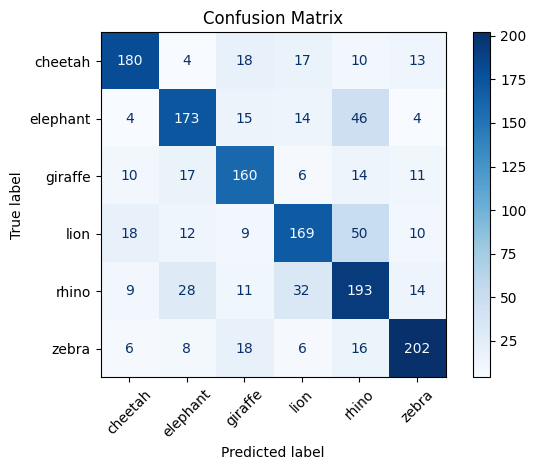

In [ ]:
import numpy as np
from scripts.obrobka.wczytaj_obrazy import load_images
from scripts.nowe_metody.hog_color_spatial import policz_hog_kolor_spatial_batch
from scripts.nowe_metody.pca_utils import (dopasuj_pca_nkomp, przeksztalc_pca)
from scripts.nowe_metody.BOVW_sift import (zbuduj_slownik_sift_bovw,policz_bovw_dla_obrazow)
from sklearn.preprocessing import StandardScaler

#HOG + kolor + spatial

print("Liczenie HOG+kolor+spatial (RGB + HSV + 2x2)...")
X_train_hog = policz_hog_kolor_spatial_batch(train_images)
X_test_hog = policz_hog_kolor_spatial_batch(test_images)
print("Kształt HOG+kolor+spatial train:", X_train_hog.shape)
print("Kształt HOG+kolor+spatial test:", X_test_hog.shape)

#etykiety
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print("Klasy:", class_names)
print("Przykładowe etykiety train:", y_train[:10])

#PCA na HOG+kolor+spatial
print("PCA na HOG...")
pca, X_train_hog_pca = dopasuj_pca_nkomp(X_train_hog, n_components=384) #zwiększam do 384 z 256
X_test_hog_pca = przeksztalc_pca(pca, X_test_hog)
print("Kształt HOG_PCA train:", X_train_hog_pca.shape)
print("Kształt HOG_PCA test:", X_test_hog_pca.shape)

#skalowanie HOG_PCA
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog_pca)
X_test_hog_scaled = scaler_hog.transform(X_test_hog_pca)

#BoVW (SIFT)
from scripts.nowe_metody.BOVW_sift import zbuduj_slownik_sift_bovw, policz_bovw_dla_obrazow

print("\nBudowa słownika BoVW (SIFT + MiniBatchKMeans)...")
sift, kmeans = zbuduj_slownik_sift_bovw(
    train_images,
    n_clusters=768,       #liczba 'słów wizualnych'  ZWIĘKSZAM DO 512 z 256
    max_images=2500,      #ile max obrazów do budowy słownika
    max_kp_per_image=400, #max kluczowych punktów na obraz
    random_state=42,
)

print("Liczenie histogramów BoVW dla train/test...")
X_train_bovw = policz_bovw_dla_obrazow(train_images, sift, kmeans, max_kp_per_image=600) #ZWIĘKSZAM do 300 z 200
X_test_bovw = policz_bovw_dla_obrazow(test_images, sift, kmeans, max_kp_per_image=600) #ZWIĘKSZAM do 300 z 200
print("Kształt BoVW train:", X_train_bovw.shape)
print("Kształt BoVW test:", X_test_bovw.shape)
#===========
# --- NORMALIZACJA BoVW (power + L2) ---
X_train_bovw = np.sqrt(np.clip(X_train_bovw, 0, None))
X_test_bovw  = np.sqrt(np.clip(X_test_bovw, 0, None))

X_train_bovw = X_train_bovw / (np.linalg.norm(X_train_bovw, axis=1, keepdims=True) + 1e-12)
X_test_bovw  = X_test_bovw  / (np.linalg.norm(X_test_bovw,  axis=1, keepdims=True) + 1e-12)

#===========

scaler_bovw = StandardScaler(with_mean=False)  # bez mean (dla znormalizowanych histogramów bywa stabilniej)
X_train_bovw_scaled = scaler_bovw.fit_transform(X_train_bovw)
X_test_bovw_scaled  = scaler_bovw.transform(X_test_bovw)

#nowosc-------
from sklearn.decomposition import PCA
print("PCA na BoVW...")
pca_bovw = PCA(n_components=160)
X_train_bovw_pca = pca_bovw.fit_transform(X_train_bovw_scaled)
X_test_bovw_pca = pca_bovw.transform(X_test_bovw_scaled)

print("Nowe kształty BoVW_PCA:", X_train_bovw_pca.shape, X_test_bovw_pca.shape)

#COMBO --> [HOG_PCA | BoVW]
X_train_combo = np.hstack([X_train_hog_scaled, X_train_bovw_pca])
X_test_combo = np.hstack([X_test_hog_scaled, X_test_bovw_pca])

#-------------

print("Kształt CECH COMBO train:", X_train_combo.shape)
print("Kształt CECH COMBO test:", X_test_combo.shape)

#SVM na cechach combo
print("Trenowanie SVMClassifier na cechach COMBO...")
svm = SVMClassifier(C=3.0, kernel="rbf", gamma="scale")
svm.fit(X_train_combo, y_train)

print("Predykcja na zbiorze testowym (COMBO)...")
y_pred = svm.predict(X_test_combo)

accuracy, precision, recall, specificity, f1, balanced_acc = calculate_metrics(y_test, y_pred)

print("Metryki SVM (COMBO: HOG_PCA + BoVW):")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"Specificity:       {specificity:.4f}")
print(f"F1 (macro):        {f1:.4f}")
print(f"Balanced accuracy: {balanced_acc:.4f}")

plot_confusion_matrix(y_test, y_pred, labels=class_names)


## Stabilne 70 % skuteczności

przygotować tekstury dla każdego zwierzęcia od każdej strony (3 sdtrony pamietajac o Lwie i Lwicy)
następnie szukac wzorca na obrazie --> i połączyć z naszym Hogiem tym ostatecznym

BOVW jest w porzadku generalnie !!

Sprawdzić, jakie wyniki osiągneły sieci z użycyiem naszego zbioru -10% i to powinnismy starac sie osiagnac

wymieszac żeby pokazać różne skuteczności


In [ ]:
https://www.sciencedirect.com/science/article/pii/S1574954124000839

--- WCZYTYWANIE DANYCH ---
Liczba obrazów train: 6107
Klasy: ['cheetah', 'elephant', 'giraffe', 'lion', 'rhino', 'zebra']

--- ETAP 1: HOG + KOLOR + SPATIAL ---
PCA na HOG...

--- ETAP 2: BoVW (SIFT) ---
Zbieram deskryptory SIFT do budowy słownika
Łączna liczba deskryptorów do KMeans: 839152
trening MiniBatchKMeans (słownik BoVW)...
Init 1/1 with method k-means++
Inertia for init 1/1: 308712256.0
[MiniBatchKMeans] Reassigning 283 cluster centers.
Minibatch step 1/83915: mean batch inertia: 103681.72
Minibatch step 2/83915: mean batch inertia: 94332.672, ewa inertia: 94332.672
Minibatch step 3/83915: mean batch inertia: 86777.104, ewa inertia: 94314.6643947123
Minibatch step 4/83915: mean batch inertia: 83680.864, ewa inertia: 94289.32026701517
Minibatch step 5/83915: mean batch inertia: 81986.8, ewa inertia: 94259.99898646916
Minibatch step 6/83915: mean batch inertia: 81303.688, ewa inertia: 94229.11949015211
Minibatch step 7/83915: mean batch inertia: 79623.704, ewa inertia: 94194.30

<Figure size 600x600 with 0 Axes>

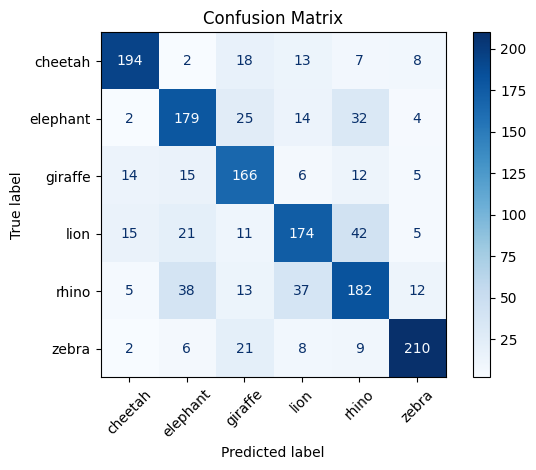

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- IMPORTY ---
from scripts.obrobka.wczytaj_obrazy import load_images
from scripts.nowe_metody.hog_color_spatial import policz_hog_kolor_spatial_batch
from scripts.nowe_metody.pca_utils import (dopasuj_pca_nkomp, przeksztalc_pca)
from scripts.nowe_metody.BOVW_sift import (zbuduj_slownik_sift_bovw, policz_bovw_dla_obrazow)
from scripts.classifiers.svm import SVMClassifier
from scripts.classifiers.metrics import calculate_metrics, plot_confusion_matrix

# POWRÓT DO TEXTURE MATCHER (ALE WERSJA ULEPSZONA)
from scripts.nowe_metody.texture_matcher import TextureMatcher

# ==========================================
# 1. WCZYTANIE DANYCH
# ==========================================
print("--- WCZYTYWANIE DANYCH ---")
train_images, train_paths = load_images("train", scaled=True)
test_images, test_paths = load_images("test", scaled=True)

train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print(f"Liczba obrazów train: {len(train_images)}")
print(f"Klasy: {class_names}")

# ==========================================
# 2. HOG + KOLOR + SPATIAL
# ==========================================
print("\n--- ETAP 1: HOG + KOLOR + SPATIAL ---")
X_train_hog = policz_hog_kolor_spatial_batch(train_images)
X_test_hog = policz_hog_kolor_spatial_batch(test_images)

print("PCA na HOG...")
pca_hog, X_train_hog_pca = dopasuj_pca_nkomp(X_train_hog, n_components=384)
X_test_hog_pca = przeksztalc_pca(pca_hog, X_test_hog)

scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog_pca)
X_test_hog_scaled = scaler_hog.transform(X_test_hog_pca)

# ==========================================
# 3. BoVW (SIFT)
# ==========================================
print("\n--- ETAP 2: BoVW (SIFT) ---")
sift, kmeans = zbuduj_slownik_sift_bovw(
    train_images,
    n_clusters=768,       
    max_images=2500,      
    max_kp_per_image=400, 
    random_state=42,
)

X_train_bovw = policz_bovw_dla_obrazow(train_images, sift, kmeans, max_kp_per_image=600)
X_test_bovw = policz_bovw_dla_obrazow(test_images, sift, kmeans, max_kp_per_image=600)

# Normalizacja
X_train_bovw = np.sqrt(np.clip(X_train_bovw, 0, None))
X_test_bovw  = np.sqrt(np.clip(X_test_bovw, 0, None))
X_train_bovw = X_train_bovw / (np.linalg.norm(X_train_bovw, axis=1, keepdims=True) + 1e-12)
X_test_bovw  = X_test_bovw  / (np.linalg.norm(X_test_bovw,  axis=1, keepdims=True) + 1e-12)

scaler_bovw = StandardScaler(with_mean=False)
X_train_bovw_scaled = scaler_bovw.fit_transform(X_train_bovw)
X_test_bovw_scaled  = scaler_bovw.transform(X_test_bovw)

# PCA na BoVW - Wracamy do stabilnego 180
print("PCA na BoVW (180)...")
pca_bovw = PCA(n_components=180)
X_train_bovw_pca = pca_bovw.fit_transform(X_train_bovw_scaled)
X_test_bovw_pca = pca_bovw.transform(X_test_bovw_scaled)

# ==========================================
# 4. TEKSTURY (Multi-Scale + CLAHE)
# ==========================================
print("\n--- ETAP 3: TEXTURE MATCHING (MULTI-SCALE) ---")
# Używamy ulepszonej klasy TextureMatcher
tex_matcher = TextureMatcher(textures_dir="dataset/textures", class_names=class_names, base_size=80)

X_train_tex = tex_matcher.compute_features(train_images)
X_test_tex = tex_matcher.compute_features(test_images)

scaler_tex = StandardScaler()
X_train_tex_scaled = scaler_tex.fit_transform(X_train_tex)
X_test_tex_scaled = scaler_tex.transform(X_test_tex)

# DELIKATNE WAŻENIE:
# Nie x3.0, bo to było za dużo. 
# x1.5 da znać SVM-owi, że te cechy są ważne, ale nie zdominuje HOG-a.
WEIGHT = 1.5
X_train_tex_scaled = X_train_tex_scaled * WEIGHT
X_test_tex_scaled = X_test_tex_scaled * WEIGHT

# ==========================================
# 5. ŁĄCZENIE (COMBO)
# ==========================================
print("\n--- ŁĄCZENIE WSZYSTKICH CECH ---")
# HOG(384) + BoVW(180) + TEX(6) = 570 cech
X_train_combo = np.hstack([X_train_hog_scaled, X_train_bovw_pca, X_train_tex_scaled])
X_test_combo = np.hstack([X_test_hog_scaled, X_test_bovw_pca, X_test_tex_scaled])

print("FINALNY kształt macierzy train:", X_train_combo.shape)

# ==========================================
# 6. TRENING SVM
# ==========================================
print("\n--- TRENING SVM ---")
svm = SVMClassifier(C=2.0, kernel="rbf", gamma="scale")
svm.fit(X_train_combo, y_train)

print("Predykcja na zbiorze testowym...")
y_pred = svm.predict(X_test_combo)

accuracy, precision, recall, specificity, f1, balanced_acc = calculate_metrics(y_test, y_pred)

print("\n=== WYNIKI KOŃCOWE (HOG + BoVW + MultiScaleTextures) ===")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1 (macro):        {f1:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

plot_confusion_matrix(y_test, y_pred, labels=class_names)

# nowe inne 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- IMPORTY ---
from scripts.obrobka.wczytaj_obrazy import load_images
from scripts.nowe_metody.hog_color_spatial import policz_hog_kolor_spatial_batch
from scripts.nowe_metody.pca_utils import (dopasuj_pca_nkomp, przeksztalc_pca)
from scripts.nowe_metody.BOVW_sift import (zbuduj_slownik_sift_bovw, policz_bovw_dla_obrazow)
from scripts.classifiers.svm import SVMClassifier
from scripts.classifiers.metrics import calculate_metrics, plot_confusion_matrix

# POWRÓT DO TEXTURE MATCHER (ALE WERSJA ULEPSZONA)
from scripts.nowe_metody.texture_matcher import TextureMatcher

# ==========================================
# 1. WCZYTANIE DANYCH
# ==========================================
print("--- WCZYTYWANIE DANYCH ---")
train_images, train_paths = load_images("train", scaled=True)
test_images, test_paths = load_images("test", scaled=True)

train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
y_train = train_df["class"].values
y_test = test_df["class"].values
class_names = sorted(train_df["class"].unique())

print(f"Liczba obrazów train: {len(train_images)}")
print(f"Klasy: {class_names}")

# ==========================================
# 2. HOG + KOLOR + SPATIAL
# ==========================================
print("\n--- ETAP 1: HOG + KOLOR + SPATIAL ---")
X_train_hog = policz_hog_kolor_spatial_batch(train_images)
X_test_hog = policz_hog_kolor_spatial_batch(test_images)

print("PCA na HOG...")
pca_hog, X_train_hog_pca = dopasuj_pca_nkomp(X_train_hog, n_components=384)
X_test_hog_pca = przeksztalc_pca(pca_hog, X_test_hog)

scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog_pca)
X_test_hog_scaled = scaler_hog.transform(X_test_hog_pca)

# ==========================================
# 3. BoVW (SIFT)
# ==========================================
print("\n--- ETAP 2: BoVW (SIFT) ---")
sift, kmeans = zbuduj_slownik_sift_bovw(
    train_images,
    n_clusters=768,       
    max_images=2500,      
    max_kp_per_image=400, 
    random_state=42,
)

X_train_bovw = policz_bovw_dla_obrazow(train_images, sift, kmeans, max_kp_per_image=600)
X_test_bovw = policz_bovw_dla_obrazow(test_images, sift, kmeans, max_kp_per_image=600)

# Normalizacja
X_train_bovw = np.sqrt(np.clip(X_train_bovw, 0, None))
X_test_bovw  = np.sqrt(np.clip(X_test_bovw, 0, None))
X_train_bovw = X_train_bovw / (np.linalg.norm(X_train_bovw, axis=1, keepdims=True) + 1e-12)
X_test_bovw  = X_test_bovw  / (np.linalg.norm(X_test_bovw,  axis=1, keepdims=True) + 1e-12)

scaler_bovw = StandardScaler(with_mean=False)
X_train_bovw_scaled = scaler_bovw.fit_transform(X_train_bovw)
X_test_bovw_scaled  = scaler_bovw.transform(X_test_bovw)

# PCA na BoVW - Wracamy do stabilnego 180
print("PCA na BoVW (180)...")
pca_bovw = PCA(n_components=180)
X_train_bovw_pca = pca_bovw.fit_transform(X_train_bovw_scaled)
X_test_bovw_pca = pca_bovw.transform(X_test_bovw_scaled)

# ==========================================
# 4. TEKSTURY (Multi-Scale + CLAHE)
# ==========================================
print("\n--- ETAP 3: TEXTURE MATCHING (MULTI-SCALE) ---")
# Używamy ulepszonej klasy TextureMatcher
tex_matcher = TextureMatcher(textures_dir="dataset/textures", class_names=class_names, base_size=80)

X_train_tex = tex_matcher.compute_features(train_images)
X_test_tex = tex_matcher.compute_features(test_images)

scaler_tex = StandardScaler()
X_train_tex_scaled = scaler_tex.fit_transform(X_train_tex)
X_test_tex_scaled = scaler_tex.transform(X_test_tex)

# DELIKATNE WAŻENIE:
# Nie x3.0, bo to było za dużo. 
# x1.5 da znać SVM-owi, że te cechy są ważne, ale nie zdominuje HOG-a.
WEIGHT = 1.5
X_train_tex_scaled = X_train_tex_scaled * WEIGHT
X_test_tex_scaled = X_test_tex_scaled * WEIGHT

# ==========================================
# 5. ŁĄCZENIE (COMBO)
# ==========================================
print("\n--- ŁĄCZENIE WSZYSTKICH CECH ---")
# HOG(384) + BoVW(180) + TEX(6) = 570 cech
X_train_combo = np.hstack([X_train_hog_scaled, X_train_bovw_pca, X_train_tex_scaled])
X_test_combo = np.hstack([X_test_hog_scaled, X_test_bovw_pca, X_test_tex_scaled])

print("FINALNY kształt macierzy train:", X_train_combo.shape)

# ==========================================
# 6. TRENING SVM
# ==========================================
print("\n--- TRENING SVM ---")
svm = SVMClassifier(C=2.0, kernel="rbf", gamma="scale")
svm.fit(X_train_combo, y_train)

print("Predykcja na zbiorze testowym...")
y_pred = svm.predict(X_test_combo)

accuracy, precision, recall, specificity, f1, balanced_acc = calculate_metrics(y_test, y_pred)

print("\n=== WYNIKI KOŃCOWE (HOG + BoVW + MultiScaleTextures) ===")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1 (macro):        {f1:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

plot_confusion_matrix(y_test, y_pred, labels=class_names)